In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
df = pd.read_csv("film_reviews_202603230153.csv")

print("Size of dataset", df.shape)
df.head()

Size of dataset (10647, 14)


,id,film_id,kinopoisk_review_id,author_name,review_title,review_text,review_type,review_date_text,helpful_yes,helpful_no,review_url,position_in_top,created_at,updated_at
0,1,1,3601733,Uzhasarium TG,"И снова горничная, дворецкие уже не в моде...",Под конец года вышло несколько неплохих трилле...,positive,25 декабря 2025 | 13:10,714,213,https://www.kinopoisk.ru/user/198484752/commen...,1,2026-03-20 23:38:20.385 +0300,2026-03-20 23:38:20.385 +0300
1,2,1,3604632,anya_e,Когда Джейн Эйр встречается с Исчезнувшей,"Ну что же, посмотрела долгожданную новинку «Го...",neutral,02 января 2026 | 20:15,316,100,https://www.kinopoisk.ru/user/2486576/comment/...,2,2026-03-20 23:38:20.385 +0300,2026-03-20 23:38:20.385 +0300
2,3,1,3607154,EvaOzil,Это привелегия?,Фильмы в жанре 'обслуживающий персонал переезж...,neutral,10 января 2026 | 20:15,206,60,https://www.kinopoisk.ru/user/4670257/comment/...,3,2026-03-20 23:38:20.385 +0300,2026-03-20 23:38:20.385 +0300
3,4,1,3619812,КиноМетафор,"«Горничная»: когда сценарий ушёл в отпуск, а к...",«Горничная» с Сидни Суини - это именно тот фил...,negative,09 февраля 2026 | 09:26,129,31,https://www.kinopoisk.ru/user/14217258/comment...,4,2026-03-20 23:38:20.385 +0300,2026-03-20 23:38:20.385 +0300
4,5,1,3606775,dmitrythewind,Хорошее кино - это привилегия,"Жизнь у Милли не сахар – она живет в машине, п...",positive,09 января 2026 | 16:07,240,135,https://www.kinopoisk.ru/user/547552/comment/3...,5,2026-03-20 23:38:20.385 +0300,2026-03-20 23:38:20.385 +0300


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10647 entries, 0 to 10646
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10647 non-null  int64 
 1   film_id              10647 non-null  int64 
 2   kinopoisk_review_id  10647 non-null  int64 
 3   author_name          10644 non-null  object
 4   review_title         9019 non-null   object
 5   review_text          10647 non-null  object
 6   review_type          10647 non-null  object
 7   review_date_text     10647 non-null  object
 8   helpful_yes          10647 non-null  int64 
 9   helpful_no           10647 non-null  int64 
 10  review_url           10167 non-null  object
 11  position_in_top      10647 non-null  int64 
 12  created_at           10647 non-null  object
 13  updated_at           10647 non-null  object
dtypes: int64(6), object(8)
memory usage: 1.1+ MB


In [6]:
print(df.columns.tolist())

['id', 'film_id', 'kinopoisk_review_id', 'author_name', 'review_title', 'review_text', 'review_type', 'review_date_text', 'helpful_yes', 'helpful_no', 'review_url', 'position_in_top', 'created_at', 'updated_at']


In [8]:
mis = df.isna().sum().sort_values(ascending=False)
mis_percent = (df.isna().mean() * 100).sort_values(ascending=False)

mis_table = pd.DataFrame({
    "missing_count": mis,
    "missing_percent": mis_percent.round(2)
})

mis_table

,missing_count,missing_percent
review_title,1628,15.29
review_url,480,4.51
author_name,3,0.03
film_id,0,0.00
kinopoisk_review_id,0,0.00
id,0,0.00
review_text,0,0.00
review_type,0,0.00
helpful_yes,0,0.00
review_date_text,0,0.00


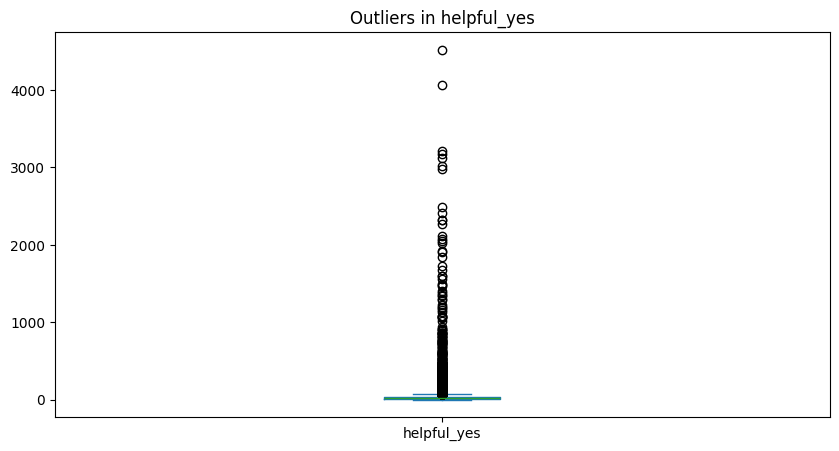

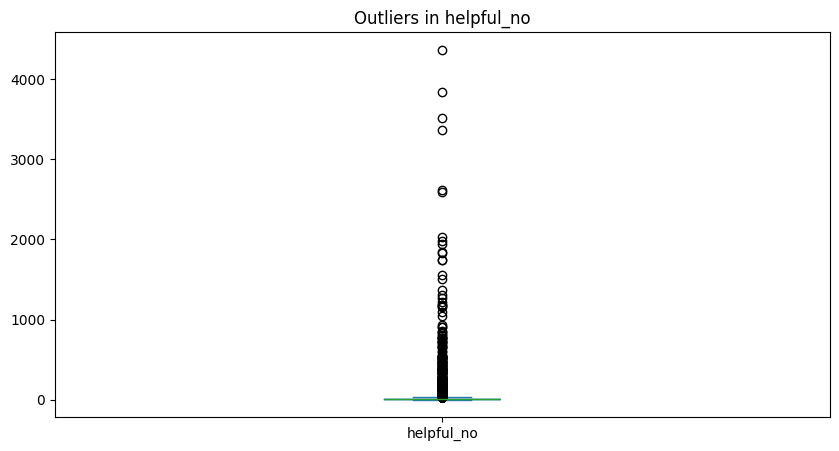

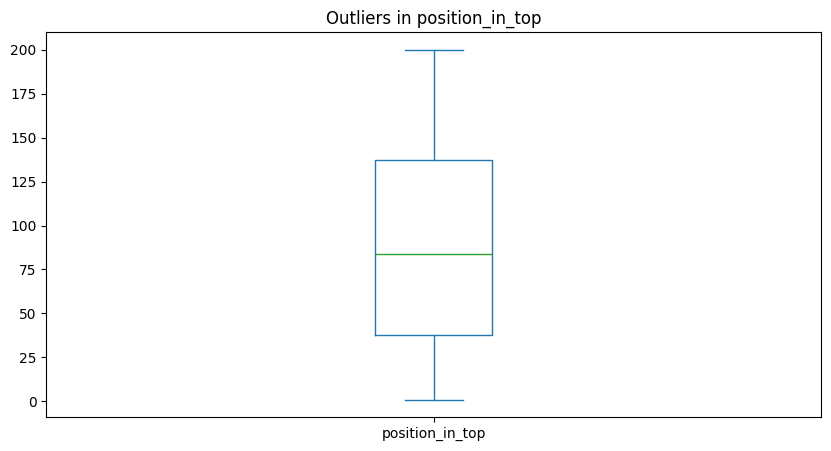

In [23]:
num_cols = ["helpful_yes", "helpful_no", "position_in_top"]

for col in num_cols:
    if col in df.columns:
        plt.figure()
        df[col].plot.box()
        plt.title(f"Outliers in {col}")
        plt.show()

In [9]:
df.describe()

,id,film_id,kinopoisk_review_id,helpful_yes,helpful_no,position_in_top
count,10647.000000,10647.000000,1.064700e+04,10647.000000,10647.000000,10647.000000
mean,5333.875082,376.310698,1.699324e+06,45.276792,21.010895,88.758054
std,3073.882357,125.511953,9.804503e+05,147.629180,115.554256,57.929244
min,1.000000,1.000000,7.457000e+03,0.000000,0.000000,1.000000
25%,2672.500000,264.000000,8.132985e+05,11.000000,2.000000,38.000000
50%,5334.000000,369.000000,1.611214e+06,20.000000,5.000000,84.000000
75%,7995.500000,487.000000,2.515396e+06,34.500000,13.000000,137.000000
max,10657.000000,585.000000,3.635345e+06,4523.000000,4368.000000,200.000000


In [11]:
print(" quantity of films", df["film_id"].nunique())
print("quantity of revies:", len(df))
print("avg revies per film:", round(df.groupby("film_id").size().mean(), 2))

 quantity of films 93
quantity of revies: 10647
avg revies per film: 114.48


review_type
positive    9017
negative     818
neutral      812
Name: count, dtype: int64


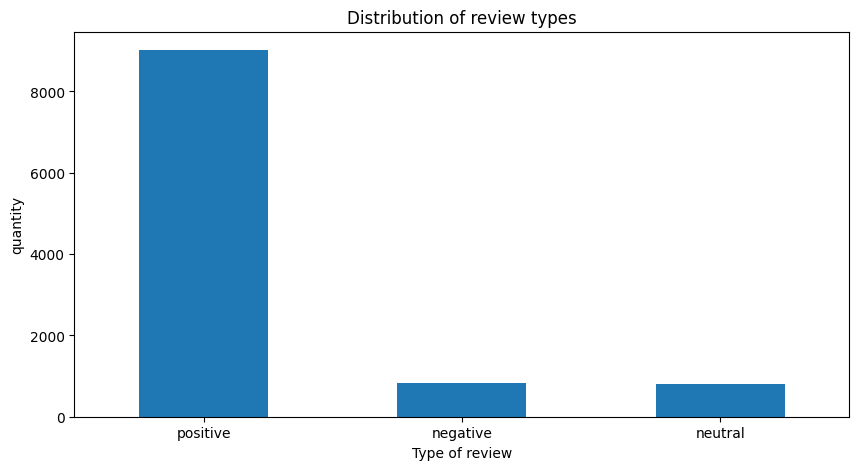

In [13]:
review_type_counts = df["review_type"].value_counts()
print(review_type_counts)

review_type_counts.plot(kind="bar")
plt.title("Distribution of review types")
plt.xlabel("Type of review")
plt.ylabel("quantity")
plt.xticks(rotation=0)
plt.show()

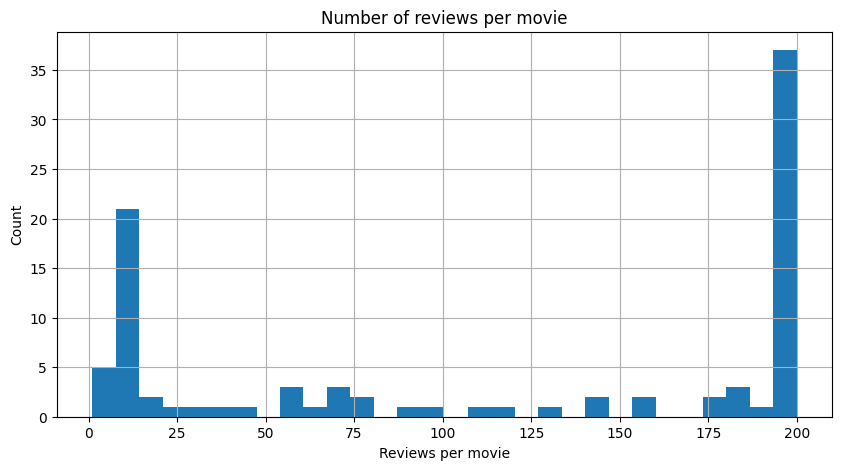

In [17]:
df.groupby("film_id").size().hist(bins=30)
plt.title("Number of reviews per movie")
plt.xlabel("Reviews per movie")
plt.ylabel("Count")
plt.show()

Most movies have a relatively small number of reviews, while only a few films accumulate a large number of reviews, indicating uneven user engagement across movies.

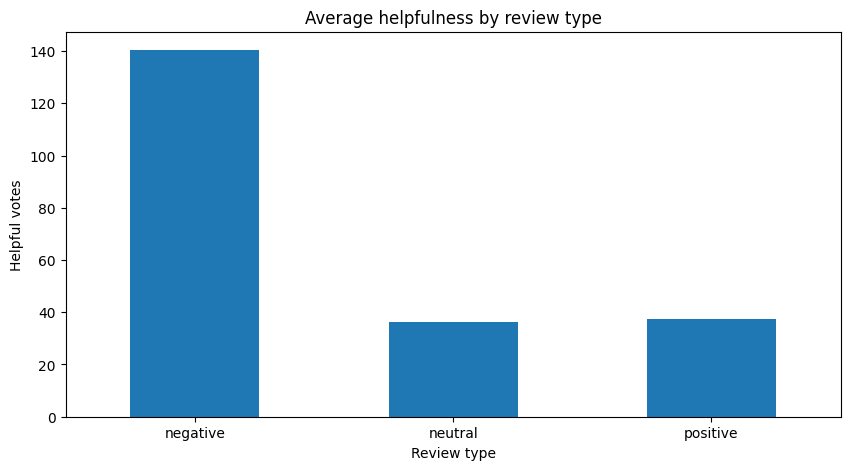

In [19]:
df.groupby("review_type")["helpful_yes"].mean().plot(kind="bar")
plt.title("Average helpfulness by review type")
plt.xlabel("Review type")
plt.ylabel("Helpful votes")
plt.xticks(rotation=0)
plt.show()

Positive reviews receive more helpful votes on average compared to negative and neutral ones, indicating higher user engagement with favorable opinions
